In [1]:
import pandas as pd
import numpy as np
import time

import seaborn as sns
import matplotlib.pyplot as plt
# Nustatyti stiliu
plt.style.use('seaborn-v0_8')

import warnings
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

## Duomenų paruošimas

In [2]:
from ucimlrepo import fetch_ucirepo

breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 

X = breast_cancer_wisconsin_original.data.features 
y = breast_cancer_wisconsin_original.data.targets 

df = pd.concat([X, y], axis=1)

### Atributų duomenų tvarkymas

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


- Matome, kad kintamieji yra gero formato: visi skaitiniai sveikieji/realieji, kaip ir turėtų būti.
- Matome, kad yra trūkstamų reikšmių kintamajame `Bare_nuclei`

In [4]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

### Klasių duomenų tvarkymas

- Klasių koduotės taisymas: į 0 ir 1

In [5]:
def recode_class(class_code):
    if class_code == 2:
        return 0
    elif class_code == 4:
        return 1
    else:
        raise ValueError(f'Data is not correct. class_code: {class_code}, class_code type: {type(class_code)}')

In [6]:
df['Class'] = df['Class'].apply(recode_class)

### Tiriamosios analizės žingsniai

- Patikriname, ar nėra išskirčių, kurias reikėtų pašalinti.
- Ištiriame skaitines charakteristikas

In [7]:
df.groupby('Class').mean()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
Class,,,,,,,,,
0,2.963964,1.306306,1.414414,1.346847,2.108108,1.346847,2.083333,1.261261,1.065315
1,7.188285,6.577406,6.560669,5.585774,5.326360,7.627615,5.974895,5.857741,2.602510


In [8]:
df.groupby('Class').median()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
Class,,,,,,,,,
0,3.0,1.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0
1,8.0,6.0,6.0,5.0,5.0,10.0,7.0,6.0,1.0


### Paskutiniai duomenų paruošimo žingsniai

- Permaišome duomenis
- Padalijame duomenis į treniravimo, validavimo ir testavimo rinkinius

In [9]:
df.index = np.random.permutation(df.index)
df.head(10)

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
574,5,1,1,1,2,1.0,3,1,1,0
540,5,4,4,5,7,10.0,3,2,1,0
470,3,1,1,1,2,2.0,3,1,1,0
256,6,8,8,1,3,4.0,3,7,1,0
314,4,1,1,3,2,1.0,3,1,1,0
251,8,10,10,8,7,10.0,9,7,1,1
282,1,1,1,1,2,10.0,3,1,1,0
274,2,1,2,1,2,1.0,3,1,1,0
324,2,1,1,1,2,1.0,1,1,5,0
660,4,2,1,1,2,1.0,2,1,1,0


In [10]:
X = df.drop(columns=['Class'])
y = df['Class']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
train_ratio = 0.8
validation_ratio = 0.1
test_ratio = 0.1

# Kodas iš stackoverflow https://datascience.stackexchange.com/questions/15135/train-test-validation-set-splitting-in-sklearn:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1 - train_ratio)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=test_ratio/(test_ratio + validation_ratio)) 

print(X_train.shape, X_val.shape, X_test.shape)

(546, 9) (68, 9) (69, 9)


# Neurono implementacija

In [13]:
AKTIVACIJOS_FUNKCIJOS = {
    'slenkstine': lambda x: 1 if x >= 0 else 0,
    'sigmoidine': lambda x: 1 / (1 + np.exp(-1 * x))
}

In [14]:
class PaprastasNeuronas:
    def __init__(self, activation: str):
        assert activation in AKTIVACIJOS_FUNKCIJOS,\
            'Pateikite sigmodine arba slekstine aktyvacijos funkcija'

        self.activation = AKTIVACIJOS_FUNKCIJOS[activation]
        self.initialize_weights()

    def initialize_weights(self):
        """ Inicializuojami svoriai pagal Xavier incializaciją. n - 9 """
        np.random.seed(42)
        # Pradedam nuo nuliu, bet po to iskarto visiems, iskyrus poslinkiui priskiriam skaiciu pagal Xavier incializacija
        self.weights = np.zeros( 10 )
        self.weights[1:] = np.random.uniform( low = -1/3, high = 1/3, size = (9,) )

    def __call__(self, x: np.ndarray):

        # Atskiriame svorius nuo poslinkio
        weights = self.weights[1:]
        bias = self.weights[0]
    
        a = np.dot( weights, x ) + bias
        z = self.activation(a)
        return z

    def predict(self, x: np.ndarray):
        return 1 if self(x) >= 0.5 else 0

    def print_weights(self) -> None:
        print("Svoriai:", self.weights[1:], "\nPoslinkis:", self.weights[0])

In [15]:
def evaluate_dataset(self, X: pd.DataFrame) -> np.array:
    outputs = []

    for x_input_pd in X.iterrows():
        x_input = x_input_pd[1].values
        outputs.append( self(x_input) )

    return np.array(outputs)

setattr(PaprastasNeuronas, 'evaluate_dataset', evaluate_dataset)

In [16]:
def update_history(
    self,
    history: dict,
    t: pd.Series,
    y: np.ndarray,
    t_val: pd.Series,
    y_val: np.ndarray
):
    # paklaida
    history['Treniravimo paklaida'].append(
        np.mean( (y - t.values) ** 2))

    history['Validavimo paklaida'].append(
        np.mean((y_val - t_val.values) ** 2))

    # tikslumas
    history['Treniravimo tikslumas'].append(
        np.mean( (y >= 0.5) == t.values ))

    history['Validavimo tikslumas'].append(
        np.mean( (y_val >= 0.5) == t_val.values ))

    return history

setattr(PaprastasNeuronas, 'update_history', update_history)

In [17]:
X.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
574,5,1,1,1,2,1.0,3,1,1
540,5,4,4,5,7,10.0,3,2,1
470,3,1,1,1,2,2.0,3,1,1
256,6,8,8,1,3,4.0,3,7,1
314,4,1,1,3,2,1.0,3,1,1


In [18]:
X.values[1, 8]

np.float64(1.0)

In [19]:
def backpropagate_sgd(
    self,
    X: pd.DataFrame,
    t: pd.Series,
    X_val: pd.DataFrame,
    t_val: pd.Series,
    lr: float = 1e-3,
    epochs: int = 150,
    e_min: float = 10
):
    total_error = np.inf
    epoch = 0

    # Skaicius kintamuju - n, skaicius stebejimu - m
    n = X.shape[1]
    m = X.shape[0]

    # Stebime laika pazingsniui
    total_time = 0

    history = {
        'Treniravimo paklaida': [],
        'Validavimo paklaida': [],
        'Treniravimo tikslumas': [],
        'Validavimo tikslumas': []
    }

    # Kartojame, kol nepasiekta norima paklaida ar epochu skaicius
    while total_error > e_min and epoch < epochs:

        # Sekame laika ir paklaida
        start = time.time()
        total_error = 0

        # Apskaiciuojame neuroninio tinklo isvesti su treniravimo ir validavimo duomenimis
        y = self.evaluate_dataset(X)
        y_val = self.evaluate_dataset(X_val)

        for i in range(m):

            # Pasiimti i-taja y (isvesties) ir t (tikraja) reiksmes
            # x_ik - k-tojo kintamojo i-toji reiksme
            for k in range(n):
                y_i = y[i]
                t_i = t.values[i]

                if k == 0:
                    # w_k siuo atveju poslinkis
                    x_ik = 1
                else:
                    # w_k siuo atveju yra svoris
                    x_ik = X.values[i, k-1]

                # Atnaujiname svorius
                update = (y_i - t_i) * y_i * (1 - y_i) * x_ik
                self.weights[k] -= lr * update

                # Atnaujinama paklaida
                total_error += (y_i - t_i) ** 2

        epoch += 1
        end = time.time()

        total_time += end - start
        history = self.update_history(history, t, y, t_val, y_val)

    return history, total_time

setattr(PaprastasNeuronas, 'backpropagate_sgd', backpropagate_sgd)

In [20]:
neuronas_sgd = PaprastasNeuronas('sigmoidine')
history_sgd, time_sgd = neuronas_sgd.backpropagate_sgd(X_train, y_train, X_val, y_val)

print("Treniruotės laikas:", time_sgd, "s")

Treniruotės laikas: 9.071958065032959 s


In [21]:
sgd_history_df = pd.DataFrame(history_sgd)

In [22]:
y_pred = [neuronas_sgd.predict(x_in[1].values) for x_in in X_test.iterrows()]
y_true = y_test

np.mean( y_pred == y_true ), np.mean( (y_pred - y_true) ** 2)

(np.float64(0.9855072463768116), np.float64(0.014492753623188406))

In [23]:
neuronas_sgd.print_weights()

Svoriai: [-0.15081133  0.61784891  0.19951914 -0.0100263  -0.60961907  0.50237318
 -0.26693556  0.27641879  0.06741001] 
Poslinkis: -1.5341803446444164


In [24]:
history_sgd['Treniravimo paklaida'][-1], history_sgd['Treniravimo tikslumas'][-1]

(np.float64(0.06145157691079616), np.float64(0.9340659340659341))

In [25]:
history_sgd['Validavimo paklaida'][-1], history_sgd['Validavimo tikslumas'][-1]

(np.float64(0.07028252096429481), np.float64(0.9264705882352942))

In [26]:
def backpropagate_paketinis(
    self,
    X: pd.DataFrame,
    t: pd.Series,
    X_val: pd.DataFrame,
    t_val: pd.Series,
    lr: float = 1e-3,
    epochs: int = 150,
    e_min: float = 10
):
    total_error = np.inf
    epoch = 0

    # Skaicius kintamuju - n, skaicius stebejimu - m
    n = X.shape[1]
    m = X.shape[0]

    # Stebime laika pazingsniui
    total_time = 0

    history = {
        'Treniravimo paklaida': [],
        'Validavimo paklaida': [],
        'Treniravimo tikslumas': [],
        'Validavimo tikslumas': []
    }

    # Kartojame, kol nepasiekta norima paklaida ar epochu skaicius
    while total_error > e_min and epoch < epochs:

        # Sekame laika ir paklaida
        start = time.time()
        total_error = 0

        # Apskaiciuojame neuroninio tinklo isvesti su treniravimo ir validavimo duomenimis
        y = self.evaluate_dataset(X)
        y_val = self.evaluate_dataset(X_val)

        # Sekame gradienta
        gradient_sum = np.zeros( 10 )

        for i in range(m):

            # Pasiimti i-taja y (isvesties) ir t (tikraja) reiksmes
            # x_ik - k-tojo kintamojo i-toji reiksme
            for k in range(n):
                y_i = y[i]
                t_i = t.values[i]

                if k == 0:
                    # w_k siuo atveju poslinkis
                    x_ik = 1
                else:
                    # w_k siuo atveju yra svoris
                    x_ik = X.values[i, k-1]

                # Atnaujiname gradienta
                gradient_sum[k] += (y_i - t_i) * y_i * (1 - y_i) * x_ik

            # Atnaujinama paklaida
            total_error += (y_i - t_i) ** 2

        # Atnaujinami svoriai
        for k in range(n):
            self.weights[k] -= lr * gradient_sum[k] / m

        epoch += 1
        end = time.time()

        total_time += end - start
        history = self.update_history(history, t, y, t_val, y_val)

    return history, total_time

setattr(PaprastasNeuronas, 'backpropagate_paketinis', backpropagate_paketinis)

In [27]:
neuronas_batch = PaprastasNeuronas('sigmoidine')
history_batch, time_batch = neuronas_batch.backpropagate_paketinis(X_train, y_train, X_val, y_val)

print("Treniruotės laikas:", time_batch, "s")

Treniruotės laikas: 8.83168339729309 s


In [28]:
y_pred = [neuronas_batch.predict(x_in[1].values) for x_in in X_test.iterrows()]
y_true = y_test

np.mean( y_pred == y_true ), np.mean( (y_pred - y_true) ** 2)

(np.float64(0.7681159420289855), np.float64(0.2318840579710145))

In [29]:
neuronas_batch.print_weights()

Svoriai: [-0.08012445  0.31310012  0.1670433   0.07573658 -0.22629608 -0.20584722
 -0.28676069  0.25439783  0.06741001] 
Poslinkis: -0.004668467768197867


In [30]:
batch_history_df = pd.DataFrame(history_batch)

In [31]:
history_batch['Treniravimo paklaida'][-1], history_batch['Treniravimo tikslumas'][-1]

(np.float64(0.21248097572741434), np.float64(0.7472527472527473))

In [32]:
history_batch['Validavimo paklaida'][-1], history_batch['Validavimo tikslumas'][-1]

(np.float64(0.23596878036041952), np.float64(0.75))

# Analizė

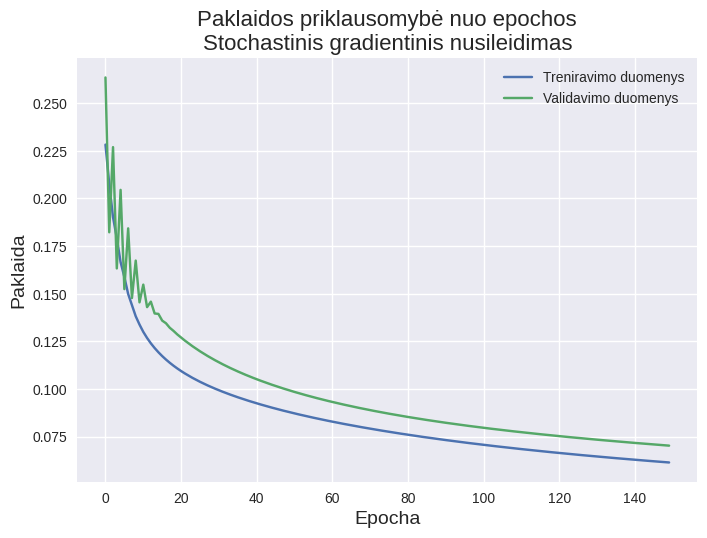

In [33]:
plt.plot(sgd_history_df['Treniravimo paklaida'], label='Treniravimo duomenys')
plt.plot(sgd_history_df['Validavimo paklaida'], label='Validavimo duomenys')

plt.xlabel('Epocha', fontsize=14)
plt.ylabel('Paklaida', fontsize=14)
plt.title('Paklaidos priklausomybė nuo epochos\nStochastinis gradientinis nusileidimas',
          fontsize=16)

plt.legend()
plt.savefig('MSE_fig_sgd.png', dpi=2000)
plt.show()

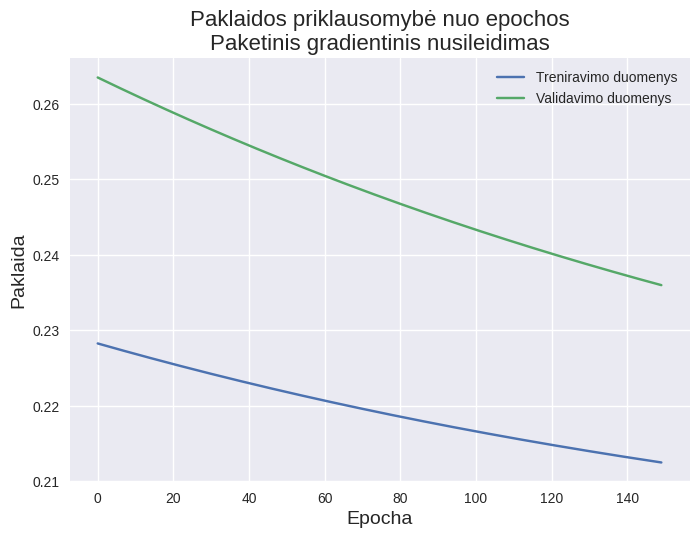

In [34]:
plt.plot(batch_history_df['Treniravimo paklaida'], label='Treniravimo duomenys')
plt.plot(batch_history_df['Validavimo paklaida'], label='Validavimo duomenys')

plt.xlabel('Epocha', fontsize=14)
plt.ylabel('Paklaida', fontsize=14)
plt.title('Paklaidos priklausomybė nuo epochos\nPaketinis gradientinis nusileidimas', fontsize=16)

plt.legend()
plt.savefig('MSE_fig_batch.png', dpi=1000)
plt.show()

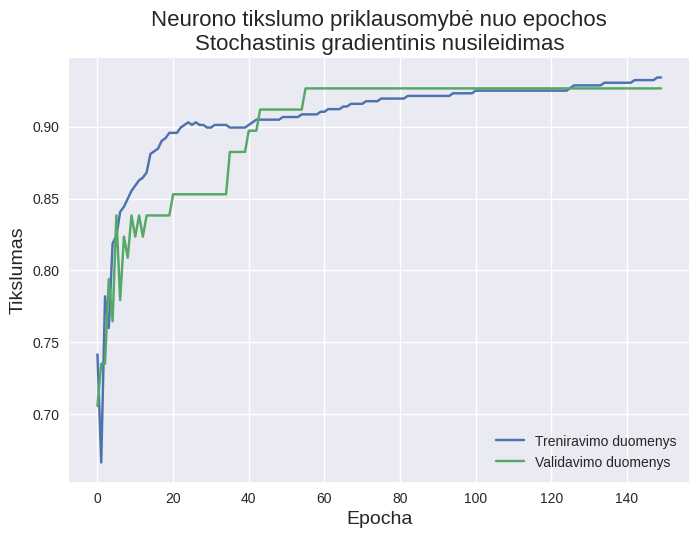

In [35]:
plt.plot(sgd_history_df['Treniravimo tikslumas'], label='Treniravimo duomenys')
plt.plot(sgd_history_df['Validavimo tikslumas'], label='Validavimo duomenys')

plt.xlabel('Epocha', fontsize=14)
plt.ylabel('Tikslumas', fontsize=14)
plt.title('Neurono tikslumo priklausomybė nuo epochos\nStochastinis gradientinis nusileidimas',
          fontsize=16)

plt.legend()
plt.savefig('acc_fig_sgd.png', dpi=1000)
plt.show()

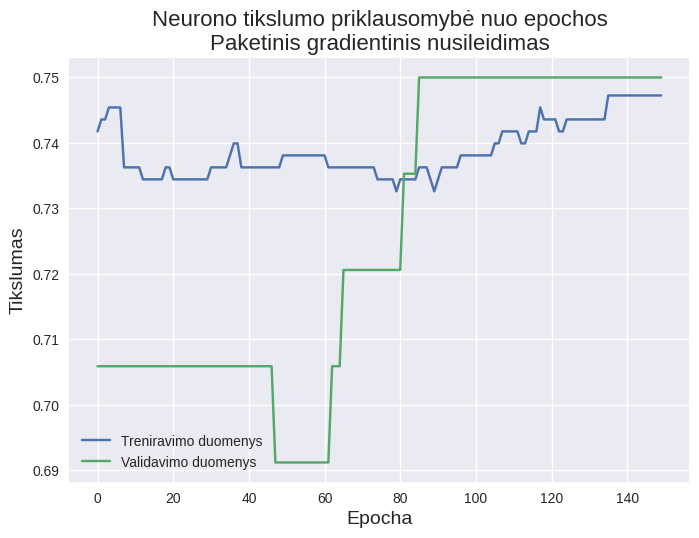

In [36]:
plt.plot(batch_history_df['Treniravimo tikslumas'], label='Treniravimo duomenys')
plt.plot(batch_history_df['Validavimo tikslumas'], label='Validavimo duomenys')

plt.xlabel('Epocha', fontsize=14)
plt.ylabel('Tikslumas', fontsize=14)
plt.title('Neurono tikslumo priklausomybė nuo epochos\nPaketinis gradientinis nusileidimas',
          fontsize=16)

plt.legend()
plt.savefig('acc_fig.png', dpi=1000)
plt.show()

In [37]:
learning_rates = [1e-5, 1e-3, 1e-1]

accuracies_sgd = []
accuracies_batch = []

mse_sgd = []
mse_batch = []

for lr in learning_rates:
    neuronas = PaprastasNeuronas('sigmoidine')
    _ = neuronas.backpropagate_sgd(X_train, y_train, X_val, y_val, lr=lr)

    y_true = y_test
    y_pred = neuronas.evaluate_dataset(X_test)

    acc = np.mean( (y_pred >= 0.5) == y_true )
    accuracies_sgd.append( acc)

    mse = np.mean( (y_pred - y_true) ** 2 )
    mse_sgd.append(mse)
    
    neuronas = PaprastasNeuronas('sigmoidine')
    _ = neuronas.backpropagate_paketinis(X, y, X_val, y_val, lr=lr)

    y_true = y_train
    y_pred = neuronas.evaluate_dataset(X_train)

    acc = np.mean( (y_pred >= 0.5) == y_true )
    accuracies_batch.append( acc)
    
    mse = np.mean( (y_pred - y_true) ** 2 )
    mse_batch.append(mse)

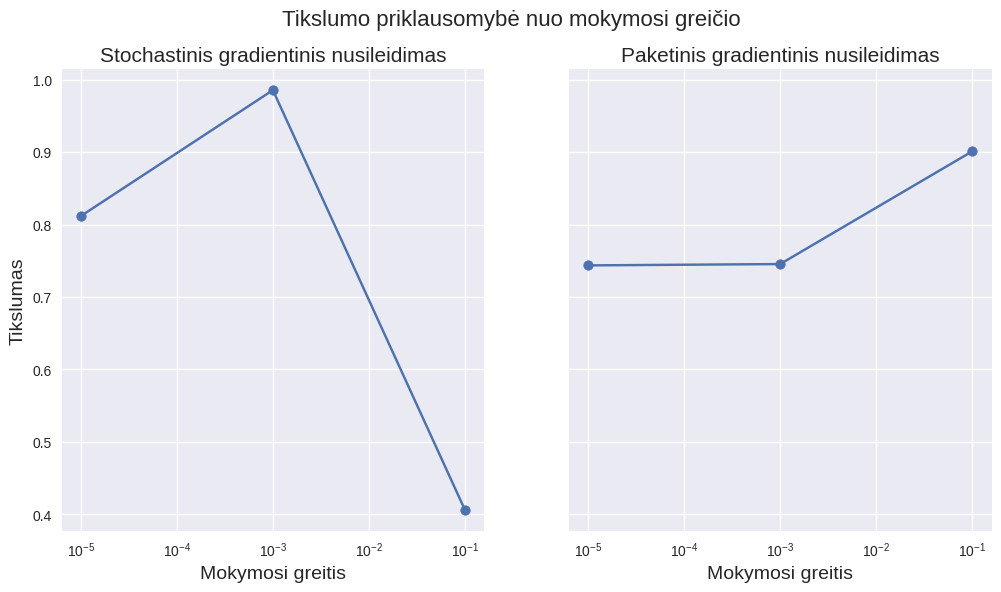

In [38]:
fig, axs = plt.subplots(ncols=2, sharey=True, figsize=(12, 6))

axs[0].plot(learning_rates, accuracies_sgd)
axs[1].plot(learning_rates, accuracies_batch)

axs[0].scatter(learning_rates, accuracies_sgd)
axs[1].scatter(learning_rates, accuracies_batch)

axs[0].set_xscale('log')
axs[1].set_xscale('log')

axs[0].set_title('Stochastinis gradientinis nusileidimas', fontsize=15)
axs[1].set_title('Paketinis gradientinis nusileidimas', fontsize=15)

axs[0].set_ylabel('Tikslumas', fontsize=14)
axs[0].set_xlabel('Mokymosi greitis', fontsize=14)
axs[1].set_xlabel('Mokymosi greitis', fontsize=14)

fig.suptitle('Tikslumo priklausomybė nuo mokymosi greičio', fontsize=16)

plt.savefig('lr_acc.png', dpi=2000)
plt.show()

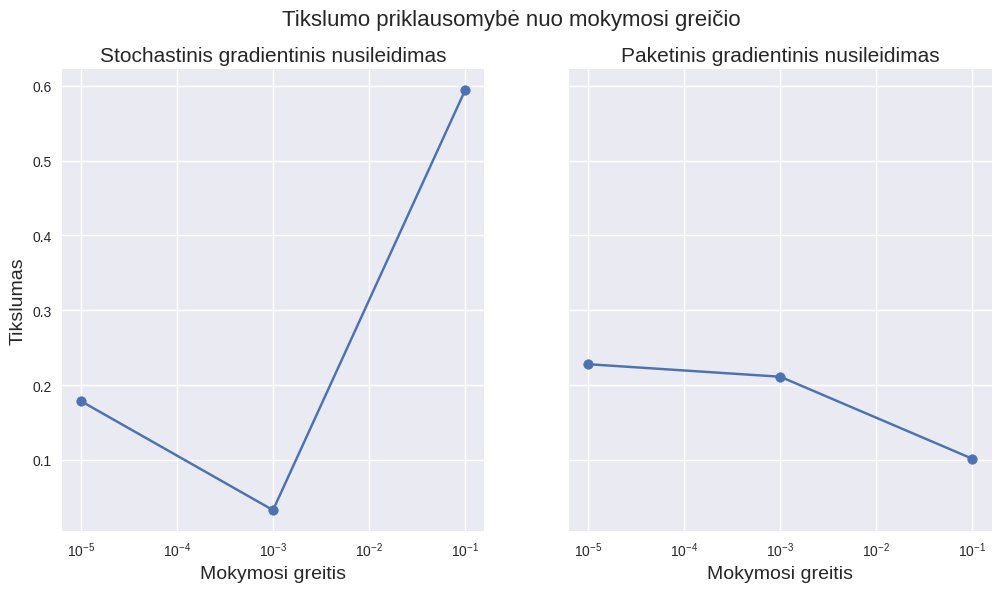

In [39]:
fig, axs = plt.subplots(ncols=2, sharey=True, figsize=(12, 6))

axs[0].plot(learning_rates, mse_sgd)
axs[1].plot(learning_rates, mse_batch)

axs[0].scatter(learning_rates, mse_sgd)
axs[1].scatter(learning_rates, mse_batch)

axs[0].set_xscale('log')
axs[1].set_xscale('log')

axs[0].set_title('Stochastinis gradientinis nusileidimas', fontsize=15)
axs[1].set_title('Paketinis gradientinis nusileidimas', fontsize=15)

axs[0].set_ylabel('Tikslumas', fontsize=14)
axs[0].set_xlabel('Mokymosi greitis', fontsize=14)
axs[1].set_xlabel('Mokymosi greitis', fontsize=14)

fig.suptitle('Tikslumo priklausomybė nuo mokymosi greičio', fontsize=16)

plt.savefig('lr_mse.png', dpi=2000)
plt.show()

In [46]:
output = {
    'Tipas': [],
    'Laikas': []
}

for i in range(10):

    neuronas = PaprastasNeuronas('sigmoidine')
    
    if i % 2 == 0:
        output['Tipas'].append('Stochastinis')
        _, time_spent = neuronas.backpropagate_sgd(X_train, y_train, X_val, y_val, lr=1e-3)

    else:
        output['Tipas'].append('Paketinis')
        _, time_spent = neuronas.backpropagate_paketinis(X_train, y_train, X_val, y_val, lr=1e-1)

    output['Laikas'].append(time_spent)

In [47]:
output = pd.DataFrame(output)

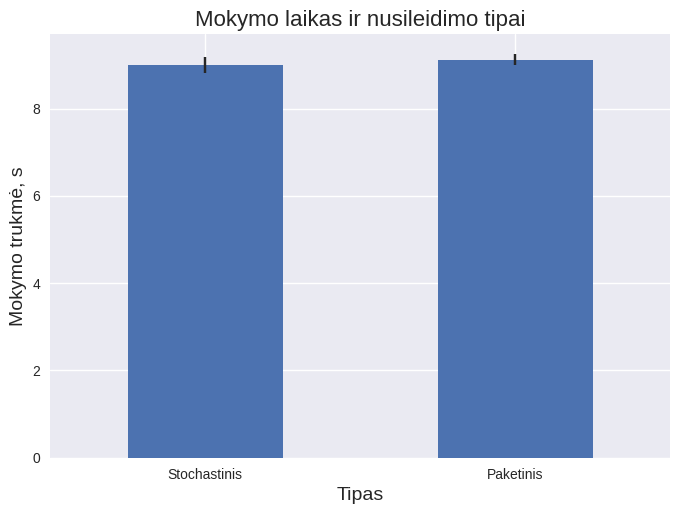

In [48]:
df_laikas = pd.DataFrame({'Tipas': output['Tipas'].unique()})

df_laikas['Laikas'] = output.groupby('Tipas')['Laikas'].mean().values
df_laikas['yerr'] = 2 * output.groupby('Tipas')['Laikas'].std().values

df_laikas.plot(kind='bar', x='Tipas', y='Laikas', yerr='yerr', legend=False)

plt.ylabel('Mokymo trukmė, s', fontsize=14)
plt.xlabel('Tipas', fontsize=14)
plt.title('Mokymo laikas ir nusileidimo tipai', fontsize=16)
plt.xticks(rotation=0)

plt.savefig('laikas.png', dpi=2000)
plt.show()

In [98]:
output = {
    'Tipas': [],
    'Paklaida': [],
    'Tikslumas': []
}

In [99]:
output['Tipas'].append( 'Stochastinis' )

neuronas = PaprastasNeuronas('sigmoidine')
_, _ = neuronas.backpropagate_sgd(X_train, y_train, X_val, y_val, lr=1e-3)

y_pred = neuronas.evaluate_dataset(X_test)
y_true = y_test

acc = np.mean( (y_pred >= 0.5) == y_true )
output['Tikslumas'].append( acc )

loss = np.mean( (y_true - y_pred) ** 2 )
output['Paklaida'].append( loss )

In [100]:
output['Tipas'].append( 'Paketinis' )

neuronas = PaprastasNeuronas('sigmoidine')
_, _ = neuronas.backpropagate_paketinis(X_train, y_train, X_val, y_val, lr=1e-1)

y_pred = neuronas.evaluate_dataset(X_test)
y_true = y_test

acc = np.mean( (y_pred >= 0.5) == y_true )
output['Tikslumas'].append( acc )

loss = np.mean( (y_true - y_pred) ** 2 )
output['Paklaida'].append( loss )

In [101]:
output = pd.DataFrame( output )

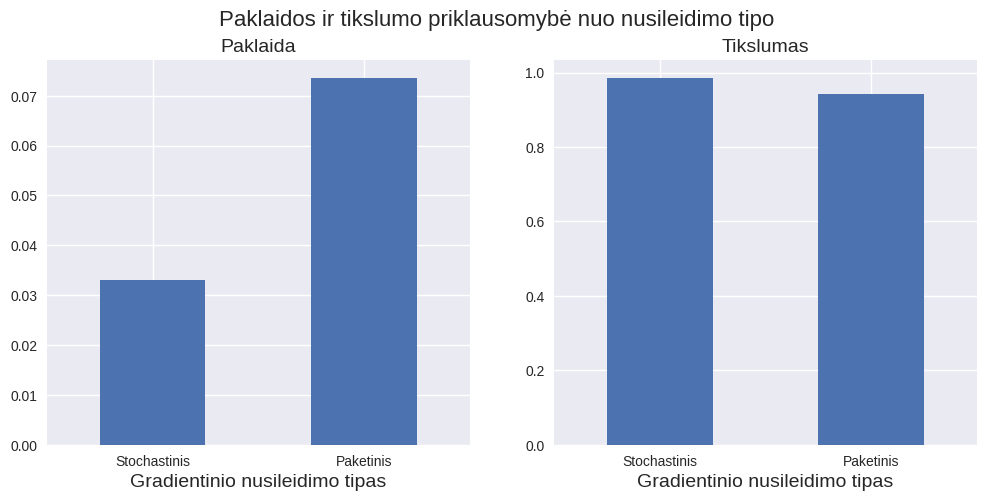

In [103]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

output.plot(kind='bar', x='Tipas', y='Paklaida', ax=axs[0], legend=False)

axs[0].set_ylabel('')
axs[0].set_xlabel('Gradientinio nusileidimo tipas', fontsize=14)
axs[0].set_title('Paklaida', fontsize=14)

output.plot(kind='bar', x='Tipas', y='Tikslumas', ax=axs[1], legend=False)
axs[1].set_ylabel('')
axs[1].set_xlabel('Gradientinio nusileidimo tipas', fontsize=14)
axs[1].set_title('Tikslumas', fontsize=14)

axs[0].tick_params(axis='x', labelrotation=0)
axs[0].tick_params(axis='y', labelrotation=0)
axs[1].tick_params(axis='x', labelrotation=0)
axs[1].tick_params(axis='y', labelrotation=0)

fig.suptitle('Paklaidos ir tikslumo priklausomybė nuo nusileidimo tipo',
             fontsize=16)

plt.savefig('mse_acc_methods.png', dpi=1000)

## Taigi geriausiai veikiantis neuronas - su SGD ir $\eta=0.001$

In [62]:
neuronas_sgd_final = PaprastasNeuronas('sigmoidine')
history_sgd_final, _ = neuronas_sgd_final.backpropagate_sgd(X_train, y_train, X_val, y_val)

In [63]:
neuronas_sgd_final.print_weights()

Svoriai: [-0.15081133  0.61784891  0.19951914 -0.0100263  -0.60961907  0.50237318
 -0.26693556  0.27641879  0.06741001] 
Poslinkis: -1.5341803446444164


In [105]:
history_sgd_final['Treniravimo paklaida'][-1], history_sgd_final['Treniravimo tikslumas'][-1]

(np.float64(0.06145157691079616), np.float64(0.9340659340659341))

In [106]:
history_sgd_final['Validavimo paklaida'][-1], history_sgd_final['Validavimo tikslumas'][-1]

(np.float64(0.07028252096429481), np.float64(0.9264705882352942))

In [108]:
y_pred = [neuronas_sgd_final.predict(x_in[1].values) for x_in in X_test.iterrows()]
y_true = y_test

np.mean( y_pred == y_true ), np.mean( (y_pred - y_true) ** 2)

(np.float64(0.9855072463768116), np.float64(0.014492753623188406))

In [110]:
latex_output = pd.DataFrame({
    'Tikroji reikšmė': y_true,
    'Prognozuota reikšmė': y_pred
}).to_latex()

with open('latex_output.tex', 'w') as f:
    print( latex_output, file=f )

In [75]:
history_batch['Epocha'] = list(range(150))
history_batch_df = pd.DataFrame(history_batch)

latex_output = history_batch_df.set_index('Epocha')\
    .to_latex()\
    .replace('.', ',')

with open('epoch_hisroty_batch.tex', 'w') as f:
    print( latex_output, file=f )

In [76]:
history_sgd['Epocha'] = list(range(150))
history_sgd_df = pd.DataFrame(history_sgd)

latex_output = history_sgd_df.set_index('Epocha')\
    .to_latex()\
    .replace('.', ',')

with open('epoch_hisroty_sgd.tex', 'w') as f:
    print( latex_output, file=f )

In [77]:
history_sgd_final['Epocha'] = list(range(150))
history_sgd_final_df = pd.DataFrame(history_sgd)

latex_output = history_sgd_final_df.set_index('Epocha')\
    .to_latex()\
    .replace('.', ',')

with open('epoch_history_sgd_final.tex', 'w') as f:
    print( latex_output, file=f )